In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans, DBSCAN, AgglomerativeClustering
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score, precision_score,
    recall_score, f1_score, roc_auc_score,
    confusion_matrix, classification_report
)

import warnings
warnings.filterwarnings("ignore")


In [6]:
df = pd.read_csv("data/customer_churn.csv")
df.head()
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 9 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   CustomerID        500 non-null    object
 1   Tenure            500 non-null    int64 
 2   MonthlyCharges    500 non-null    int64 
 3   TotalCharges      500 non-null    int64 
 4   Contract          500 non-null    object
 5   PaymentMethod     500 non-null    object
 6   PaperlessBilling  500 non-null    object
 7   SeniorCitizen     500 non-null    int64 
 8   Churn             500 non-null    int64 
dtypes: int64(5), object(4)
memory usage: 35.3+ KB


In [7]:
df.isnull().sum()


CustomerID          0
Tenure              0
MonthlyCharges      0
TotalCharges        0
Contract            0
PaymentMethod       0
PaperlessBilling    0
SeniorCitizen       0
Churn               0
dtype: int64

In [19]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
scaled_data = scaler.fit_transform(X_encoded)


scaler = StandardScaler()
df_clean = df.drop("CustomerID", axis=1)
X = df_clean.drop("Churn", axis=1)
y = df_clean["Churn"]
X_encoded = pd.get_dummies(X, drop_first=True)


X_encoded.head()
scaled_data.shape




(500, 9)

In [14]:
df.dtypes


CustomerID          object
Tenure               int64
MonthlyCharges       int64
TotalCharges         int64
Contract            object
PaymentMethod       object
PaperlessBilling    object
SeniorCitizen        int64
Churn                int64
dtype: object

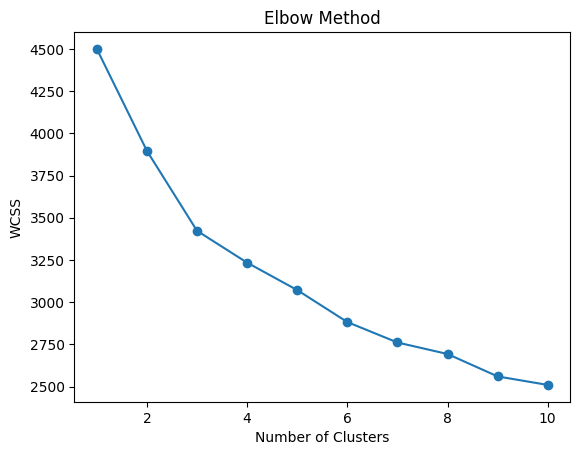

In [20]:
wcss = []

for k in range(1, 11):
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(scaled_data)
    wcss.append(kmeans.inertia_)

plt.plot(range(1, 11), wcss, marker='o')
plt.xlabel("Number of Clusters")
plt.ylabel("WCSS")
plt.title("Elbow Method")
plt.show()


In [21]:
kmeans = KMeans(n_clusters=3, random_state=42)
df["KMeans_Cluster"] = kmeans.fit_predict(scaled_data)

df.head()


,CustomerID,Tenure,MonthlyCharges,TotalCharges,Contract,PaymentMethod,PaperlessBilling,SeniorCitizen,Churn,KMeans_Cluster
0,C00001,6,64,1540,One year,Credit Card,No,1,0,1
1,C00002,21,113,1753,Month-to-month,Electronic Check,Yes,1,0,0
2,C00003,27,31,1455,Two year,Credit Card,No,1,0,2
3,C00004,53,29,7150,Month-to-month,Electronic Check,No,1,0,0
4,C00005,16,185,1023,One year,Electronic Check,No,1,0,0


In [22]:
hierarchical = AgglomerativeClustering(n_clusters=3)
df["Hierarchical_Cluster"] = hierarchical.fit_predict(scaled_data)


In [23]:
dbscan = DBSCAN(eps=0.5, min_samples=5)
df["DBSCAN_Cluster"] = dbscan.fit_predict(scaled_data)


In [25]:
segment_summary = df.groupby("KMeans_Cluster").mean(numeric_only=True)
segment_summary


,Tenure,MonthlyCharges,TotalCharges,SeniorCitizen,Churn,Hierarchical_Cluster,DBSCAN_Cluster
KMeans_Cluster,,,,,,,
0,37.452586,116.737069,4088.387931,0.469828,0.103448,0.025862,-1.0
1,37.024194,107.282258,4216.282258,0.524194,0.153226,1.895161,-1.0
2,34.625000,114.111111,4497.333333,0.520833,0.069444,0.937500,-1.0


In [26]:
segment_names = {
    0: "Premium Spenders",
    1: "Budget Conscious",
    2: "Young Professionals"
}

df["Segment_Name"] = df["KMeans_Cluster"].map(segment_names)
df.head()


,CustomerID,Tenure,MonthlyCharges,TotalCharges,Contract,PaymentMethod,PaperlessBilling,SeniorCitizen,Churn,KMeans_Cluster,Hierarchical_Cluster,DBSCAN_Cluster,Segment_Name
0,C00001,6,64,1540,One year,Credit Card,No,1,0,1,2,-1,Budget Conscious
1,C00002,21,113,1753,Month-to-month,Electronic Check,Yes,1,0,0,0,-1,Premium Spenders
2,C00003,27,31,1455,Two year,Credit Card,No,1,0,2,1,-1,Young Professionals
3,C00004,53,29,7150,Month-to-month,Electronic Check,No,1,0,0,0,-1,Premium Spenders
4,C00005,16,185,1023,One year,Electronic Check,No,1,0,0,0,-1,Premium Spenders


In [34]:
from sklearn.cluster import KMeans

kmeans = KMeans(n_clusters=3, random_state=42)
df_clean["Cluster"] = kmeans.fit_predict(scaled_data)
df_clean["Cluster"].value_counts()



Cluster
0    232
2    144
1    124
Name: count, dtype: int64

In [35]:
df_model = df.drop("CustomerID", axis=1)

df_model_encoded = pd.get_dummies(df_model, drop_first=True)

df_model_encoded.head()



df_model_encoded["Cluster"] = df_clean["Cluster"].values
df_model_encoded["Segment_Name"] = df_clean["Cluster"].map({
    0: "Premium Spenders",
    1: "Budget Conscious",
    2: "Young Professionals"
})



In [36]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score

models = {}
results = []

for segment in df_model_encoded["Segment_Name"].unique():
    
    segment_data = df_model_encoded[
        df_model_encoded["Segment_Name"] == segment
    ]
    
    X = segment_data.drop(
        ["Churn", "Cluster", "Segment_Name"], axis=1
    )
    y = segment_data["Churn"]
    
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.2, random_state=42
    )
    
    model = RandomForestClassifier(random_state=42)
    model.fit(X_train, y_train)
    
    y_pred = model.predict(X_test)
    y_prob = model.predict_proba(X_test)[:, 1]
    
    results.append({
        "Segment": segment,
        "Accuracy": accuracy_score(y_test, y_pred),
        "Precision": precision_score(y_test, y_pred),
        "Recall": recall_score(y_test, y_pred),
        "F1 Score": f1_score(y_test, y_pred),
        "ROC AUC": roc_auc_score(y_test, y_prob)
    })
    
    models[segment] = model


In [37]:
results_df = pd.DataFrame(results)
results_df


,Segment,Accuracy,Precision,Recall,F1 Score,ROC AUC
0,Budget Conscious,0.960000,0.833333,1.000000,0.909091,1.000000
1,Premium Spenders,0.957447,1.000000,0.666667,0.800000,1.000000
2,Young Professionals,0.931034,0.000000,0.000000,0.000000,0.964286


In [38]:
results_df.to_csv("model_evaluation_results.csv", index=False)


In [39]:
param_grid = {
    "n_estimators": [100, 200],
    "max_depth": [None, 10, 20],
    "min_samples_split": [2, 5]
}

grid = GridSearchCV(
    RandomForestClassifier(random_state=42),
    param_grid,
    cv=5,
    scoring="f1"
)

grid.fit(X_train, y_train)


,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",RandomForestC...ndom_state=42)
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'max_depth': [None, 10, ...], 'min_samples_split': [2, 5], 'n_estimators': [100, 200]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'f1'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",None
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"verbose verbose: intControls the verbosity: the higher, the more messages.- >1 : the computation time for each fold and parameter candidate is displayed;- >2 : the

In [40]:
grid.best_params_


{'max_depth': None, 'min_samples_split': 2, 'n_estimators': 100}

In [41]:
importances = models["Premium Spenders"].feature_importances_
features = X.columns

feature_importance = pd.DataFrame({
    "Feature": features,
    "Importance": importances
}).sort_values(by="Importance", ascending=False)

feature_importance


,Feature,Importance
0,Tenure,0.618849
1,MonthlyCharges,0.140064
2,TotalCharges,0.125940
7,Contract_One year,0.056130
3,SeniorCitizen,0.025529
10,PaymentMethod_Electronic Check,0.019415
11,PaperlessBilling_Yes,0.013523
5,Hierarchical_Cluster,0.000550
4,KMeans_Cluster,0.000000
6,DBSCAN_Cluster,0.000000


## Business Recommendations

### Premium Spenders
- Loyalty rewards
- Personalized offers

### Budget Conscious
- Discount pricing
- Cashback offers

### Young Professionals
- App-based engagement
- Flexible plans


In [42]:
segmentation_df = df_clean.copy()

segmentation_df["Segment_Name"] = segmentation_df["Cluster"].map({
    0: "Premium Spenders",
    1: "Budget Conscious",
    2: "Young Professionals"
})

segmentation_df.head()


,Tenure,MonthlyCharges,TotalCharges,Contract,PaymentMethod,PaperlessBilling,SeniorCitizen,Churn,Cluster,Segment_Name
0,6,64,1540,One year,Credit Card,No,1,0,1,Budget Conscious
1,21,113,1753,Month-to-month,Electronic Check,Yes,1,0,0,Premium Spenders
2,27,31,1455,Two year,Credit Card,No,1,0,2,Young Professionals
3,53,29,7150,Month-to-month,Electronic Check,No,1,0,0,Premium Spenders
4,16,185,1023,One year,Electronic Check,No,1,0,0,Premium Spenders


In [43]:
segmentation_df.to_csv("segmentation_data.csv", index=False)
